# 04 · Mô hình dự đoán giá xe VinFast

Notebook này xây dựng và so sánh ba mô hình hồi quy để dự đoán **giá niêm yết (triệu VNĐ)** của xe VinFast điện từ dữ liệu Chợ Tốt.  
Biến mục tiêu: `price_million` (giá ÷ 1 000 000).  
Đặc trưng đầu vào: dòng xe (`family`), tình trạng (`condition`), năm sản xuất (`year`), số km đã đi (`odo_km`), tỉnh/thành (`region`).

**Các mô hình được so sánh:**
1. Baseline – dự đoán bằng trung vị giá theo dòng xe (tính trên tập train)
2. Hồi quy tuyến tính (Linear Regression)
3. Rừng ngẫu nhiên (Random Forest Regressor)

Metrics đánh giá: MAE (triệu VNĐ) và R² trên tập kiểm định (test set 20%).

## 1. Thiết lập & Nạp dữ liệu

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

RANDOM_STATE = 42
DATA_PATH = Path('../data/processed/buyer_eda/screened_listings.csv')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Nạp toàn bộ dữ liệu
raw = pd.read_csv(DATA_PATH)
print(f'Raw data: {raw.shape[0]:,} rows × {raw.shape[1]} columns')
raw.head(3)

Raw data: 1,000 rows × 19 columns


,list_id,cohort,crawl_date,is_trackable,model_source,family,condition,year,odo_km,region,seller_key,price_vnd,scope_eligible,price_eligible,review_reasons,battery_topic,financing_mention,promo_mention,subject
0,134599448,legacy_unknown_crawl_date,NaN,False,VF8,VF8,Used,2024,42000.0,Hanoi,18315300,800000000,True,True,NaN,Both mentioned,False,True,VF8 mua pin CALT chạy hơn 4v đen quyền lực
1,134518548,legacy_unknown_crawl_date,NaN,False,VF3,VF3,New,2026,NaN,Ho Chi Minh City,26689559,278000000,True,True,NaN,Not mentioned,True,True,"VinFast VF3 Eco, Plus Điện đủ mẫu mã giá sập sàn🚨"
2,134609246,legacy_unknown_crawl_date,NaN,False,VF6,VF6,New,2026,NaN,Hanoi,2688886,575000000,True,True,NaN,Not mentioned,False,False,"VINFAST VF6 – SUV ĐIỆN HIỆN ĐẠI, THIẾT KẾ ĐẸP"


## 2. Lọc tập dữ liệu hợp lệ & tạo biến mục tiêu

Chỉ giữ lại các tin có `price_eligible == True` (đã loại bỏ các tin có giá bất thường, giá 0, hoặc có nội dung khuyến mãi gây nhiễu).  
Chuyển giá từ VNĐ sang **triệu VNĐ** để dễ diễn giải.

In [3]:
# Lọc cohort hợp lệ: scope_eligible AND price_eligible
df = raw[raw['price_eligible'] == True].copy()
df['price_million'] = df['price_vnd'] / 1_000_000

print(f'Sau khi lọc: {len(df):,} tin hợp lệ (bỏ {len(raw) - len(df):,} tin)')
print(f'\nPhân phối giá (triệu VNĐ):')
print(df['price_million'].describe().round(1))

Sau khi lọc: 915 tin hợp lệ (bỏ 85 tin)

Phân phối giá (triệu VNĐ):
count     915.0
mean      555.2
std       278.5
min       100.0
25%       288.0
50%       575.0
75%       680.0
max      1699.0
Name: price_million, dtype: float64


## 3. Chọn đặc trưng & Xử lý thiếu dữ liệu odo_km

Chiến lược xử lý `odo_km` bị thiếu:
- **Xe mới** (`condition == 'New'`): odo_km = **0** (xe chưa qua sử dụng)
- **Xe cũ** (`condition == 'Used'`): thay thế bằng **trung vị odo_km theo dòng xe** — tính *chỉ trên tập train* để tránh data leakage

In [4]:
FEATURES = ['family', 'condition', 'year', 'odo_km', 'region']
TARGET = 'price_million'
CAT_FEATURES = ['family', 'condition', 'region']
NUM_FEATURES = ['year', 'odo_km']

# Dùng cột 'region' làm province (tỉnh/thành phố)
df = df.rename(columns={'region': 'province'}).copy()
CAT_FEATURES = ['family', 'condition', 'province']

# Subset cần thiết
model_df = df[['family', 'condition', 'year', 'odo_km', 'province', TARGET]].copy()

print('Thiếu dữ liệu odo_km theo condition:')
print(model_df.groupby('condition')['odo_km'].apply(lambda x: f'{x.isna().sum()} / {len(x)} ({x.isna().mean()*100:.0f}%)'))
print(f'\nTổng số hàng: {len(model_df):,}')

Thiếu dữ liệu odo_km theo condition:
condition
New     607 / 610 (100%)
Used        0 / 305 (0%)
Name: odo_km, dtype: str

Tổng số hàng: 915


## 4. Chia tập Train / Test (80% / 20%)

In [ ]:
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Tập train: {len(X_train):,} mẫu')
print(f'Tập test:  {len(X_test):,} mẫu')
print(f'\nPhân phối condition trong train:')
print(X_train['condition'].value_counts())

Tập train: 732 mẫu
Tập test:  183 mẫu

Phân phối condition trong train:
condition
New     485
Used    247
Name: count, dtype: int64


### Xử lý odo_km sau khi chia tập

Median odo_km được tính **chỉ từ tập train** rồi áp dụng lên cả train lẫn test.

In [6]:
def impute_odo(X_tr: pd.DataFrame, X_te: pd.DataFrame):
    """Impute odo_km:
    - New  → 0
    - Used → median odo_km per family (calculated from training set only)
    Returns (X_tr_imp, X_te_imp, odo_medians)
    """
    X_tr = X_tr.copy()
    X_te = X_te.copy()

    # Xe mới → 0
    X_tr.loc[X_tr['condition'] == 'New', 'odo_km'] = X_tr.loc[
        X_tr['condition'] == 'New', 'odo_km'].fillna(0)
    X_te.loc[X_te['condition'] == 'New', 'odo_km'] = X_te.loc[
        X_te['condition'] == 'New', 'odo_km'].fillna(0)

    # Xe cũ → median per family từ train
    used_train = X_tr[X_tr['condition'] == 'Used']
    odo_medians = used_train.groupby('family')['odo_km'].median()
    global_used_median = used_train['odo_km'].median()

    def fill_used(row):
        if row['condition'] == 'Used' and pd.isna(row['odo_km']):
            return odo_medians.get(row['family'], global_used_median)
        return row['odo_km']

    X_tr['odo_km'] = X_tr.apply(fill_used, axis=1)
    X_te['odo_km'] = X_te.apply(fill_used, axis=1)

    return X_tr, X_te, odo_medians


X_train_imp, X_test_imp, odo_medians = impute_odo(X_train, X_test)

print('Giá trị trung vị odo_km theo dòng xe (Used, từ tập train):')
print(odo_medians.sort_values().to_string())
print(f'\nCòn thiếu trong train: {X_train_imp["odo_km"].isna().sum()}')
print(f'Còn thiếu trong test:  {X_test_imp["odo_km"].isna().sum()}')

Giá trị trung vị odo_km theo dòng xe (Used, từ tập train):
family
EC VAN             0.0
Minio Green        3.5
VF3            13000.0
MPV7           14000.0
Limo Green     16500.0
VF7            17800.0
VF9            18500.0
Herio Green    20000.0
VF6            32000.0
VF5            32500.0
VF8            47900.0
VFe34          52000.0
Nerio Green    67000.0

Còn thiếu trong train: 0
Còn thiếu trong test:  0


## 5. Baseline — Dự đoán bằng trung vị giá theo dòng xe

Baseline đơn giản nhất: với mỗi tin trong tập test, dự đoán giá = **trung vị giá của dòng xe đó** (tính từ train). Đây là ngưỡng tối thiểu mà một mô hình tốt phải vượt qua.

In [7]:
# Tính median giá theo family từ TẬP TRAIN
train_family_median = y_train.groupby(X_train_imp['family']).median()
overall_median = y_train.median()

print('Giá trung vị (triệu VNĐ) theo dòng xe (tập train):')
print(train_family_median.sort_values().round(1).to_string())

# Dự đoán baseline trên test
y_pred_baseline = X_test_imp['family'].map(train_family_median).fillna(overall_median)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f'\n[Baseline] MAE = {mae_baseline:.1f} triệu VNĐ  |  R² = {r2_baseline:.3f}')

Giá trung vị (triệu VNĐ) theo dòng xe (tập train):
family
VF2             180.0
Minio Green     184.0
EC VAN          266.0
VF3             269.5
VFe34           359.5
Herio Green     408.5
VF5             429.6
Nerio Green     450.0
VF6             599.0
Limo Green      639.5
MPV7            692.5
VF7             730.0
VF8             794.0
VF9            1288.0

[Baseline] MAE = 38.6 triệu VNĐ  |  R² = 0.950


## 6. Mô hình 1 — Hồi quy Tuyến tính (Linear Regression)

Sử dụng Pipeline của scikit-learn:
- **Bộ xử lý**: OneHotEncoder cho các biến phân loại (`family`, `condition`, `province`), giữ nguyên biến số (`year`, `odo_km`)
- **Mô hình**: LinearRegression

In [8]:
# Định nghĩa bộ tiền xử lý
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
    ('num', 'passthrough', NUM_FEATURES)
])

# Pipeline Linear Regression
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipe_lr.fit(X_train_imp, y_train)

y_pred_lr = pipe_lr.predict(X_test_imp)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f'[Linear Regression] MAE = {mae_lr:.1f} triệu VNĐ  |  R² = {r2_lr:.3f}')

[Linear Regression] MAE = 30.7 triệu VNĐ  |  R² = 0.970


## 7. Mô hình 2 — Rừng Ngẫu nhiên (Random Forest Regressor)

Random Forest có khả năng nắm bắt các mối quan hệ phi tuyến (ví dụ: ảnh hưởng của km chạy không tuyến tính lên giá) và ít bị ảnh hưởng bởi ngoại lệ hơn Linear Regression.

In [9]:
# Pipeline Random Forest
pipe_rf = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
        ('num', 'passthrough', NUM_FEATURES)
    ])),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

pipe_rf.fit(X_train_imp, y_train)

y_pred_rf = pipe_rf.predict(X_test_imp)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'[Random Forest]     MAE = {mae_rf:.1f} triệu VNĐ  |  R² = {r2_rf:.3f}')

[Random Forest]     MAE = 29.3 triệu VNĐ  |  R² = 0.970


## 8. So sánh các mô hình

In [10]:
results = pd.DataFrame({
    'Mô hình': ['Baseline (Median/Family)', 'Linear Regression', 'Random Forest'],
    'MAE (triệu VNĐ)': [mae_baseline, mae_lr, mae_rf],
    'R²': [r2_baseline, r2_lr, r2_rf]
})
results = results.set_index('Mô hình')
results['MAE (triệu VNĐ)'] = results['MAE (triệu VNĐ)'].round(2)
results['R²'] = results['R²'].round(4)

print('=== KẾT QUẢ SO SÁNH MÔ HÌNH (Test Set) ===')
print(results.to_string())

# Lưu kết quả để dùng trong Streamlit
results.to_csv('../data/processed/buyer_eda/model_metrics.csv')
print('\nĐã lưu metrics vào data/processed/buyer_eda/model_metrics.csv')

=== KẾT QUẢ SO SÁNH MÔ HÌNH (Test Set) ===
                          MAE (triệu VNĐ)      R²
Mô hình                                          
Baseline (Median/Family)            38.63  0.9504
Linear Regression                   30.69  0.9698
Random Forest                       29.30  0.9704

Đã lưu metrics vào data/processed/buyer_eda/model_metrics.csv


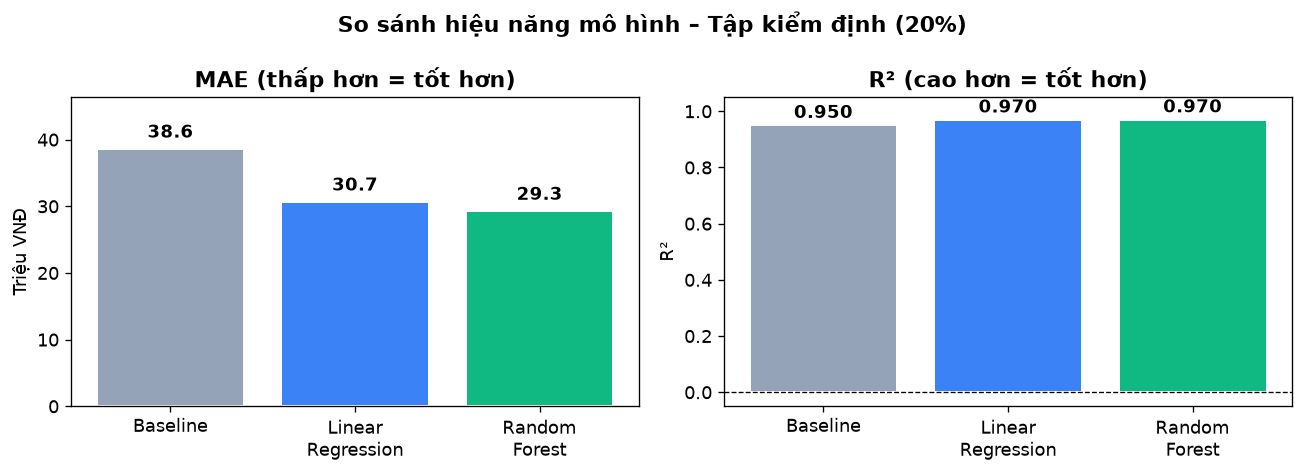

Đã lưu biểu đồ vào figures/model_comparison.png


In [11]:
# Biểu đồ cột so sánh MAE và R²
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = ['#94a3b8', '#3b82f6', '#10b981']
model_names = ['Baseline', 'Linear\nRegression', 'Random\nForest']

# MAE
bars_mae = axes[0].bar(model_names, [mae_baseline, mae_lr, mae_rf], color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('MAE (thấp hơn = tốt hơn)', fontweight='bold')
axes[0].set_ylabel('Triệu VNĐ')
for bar, val in zip(bars_mae, [mae_baseline, mae_lr, mae_rf]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_ylim(0, max(mae_baseline, mae_lr, mae_rf) * 1.2)

# R²
bars_r2 = axes[1].bar(model_names, [r2_baseline, r2_lr, r2_rf], color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('R² (cao hơn = tốt hơn)', fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars_r2, [r2_baseline, r2_lr, r2_rf]):
    y_pos = max(val + 0.01, 0.01)
    axes[1].text(bar.get_x() + bar.get_width()/2, y_pos,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylim(min(0, r2_baseline) - 0.05, 1.05)

fig.suptitle('So sánh hiệu năng mô hình – Tập kiểm định (20%)', fontsize=13, fontweight='bold')
plt.tight_layout()

fig_dir = Path('../figures')
fig_dir.mkdir(exist_ok=True)
plt.savefig(fig_dir / 'model_comparison.png', bbox_inches='tight')
plt.show()
print('Đã lưu biểu đồ vào figures/model_comparison.png')

## 9. Biểu đồ Dự đoán vs. Thực tế — Mô hình tốt nhất

Mô hình tốt nhất: Random Forest  |  MAE=29.3 triệu  |  R²=0.970


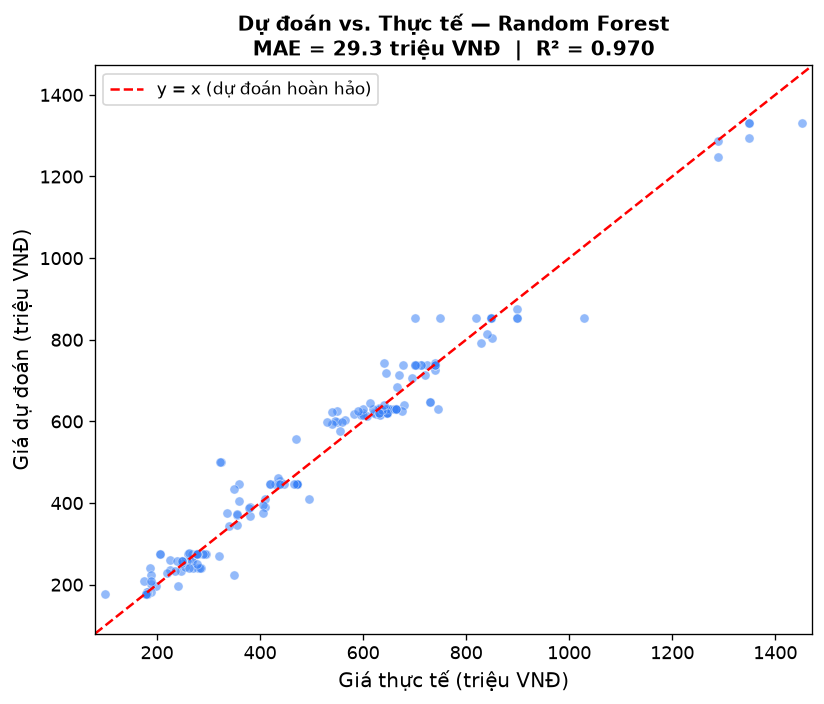

Đã lưu biểu đồ vào figures/pred_vs_actual.png


In [12]:
# Xác định mô hình tốt nhất (MAE thấp nhất)
best_idx = np.argmin([mae_baseline, mae_lr, mae_rf])
best_name = ['Baseline', 'Linear Regression', 'Random Forest'][best_idx]
best_preds = [y_pred_baseline, y_pred_lr, y_pred_rf][best_idx]
best_mae   = [mae_baseline, mae_lr, mae_rf][best_idx]
best_r2    = [r2_baseline, r2_lr, r2_rf][best_idx]

print(f'Mô hình tốt nhất: {best_name}  |  MAE={best_mae:.1f} triệu  |  R²={best_r2:.3f}')

fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(y_test, best_preds, alpha=0.55, s=30,
                c='#3b82f6', edgecolors='white', linewidths=0.4)

lims = [min(y_test.min(), best_preds.min()) - 20,
        max(y_test.max(), best_preds.max()) + 20]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='y = x (dự đoán hoàn hảo)')

ax.set_xlabel('Giá thực tế (triệu VNĐ)', fontsize=12)
ax.set_ylabel('Giá dự đoán (triệu VNĐ)', fontsize=12)
ax.set_title(f'Dự đoán vs. Thực tế — {best_name}\nMAE = {best_mae:.1f} triệu VNĐ  |  R² = {best_r2:.3f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.savefig(fig_dir / 'pred_vs_actual.png', bbox_inches='tight')
plt.show()
print('Đã lưu biểu đồ vào figures/pred_vs_actual.png')

## 10. Lưu mô hình tốt nhất

In [13]:
# Xác định và lưu pipeline tốt nhất
best_pipe = [None, pipe_lr, pipe_rf][best_idx]  # Baseline không có pipeline

if best_pipe is None:
    # Baseline thắng — lưu thông tin median
    print('Baseline thắng — không có sklearn pipeline để lưu.')
    print('Lưu Random Forest (mô hình mạnh nhất có pipeline) để dùng trong web app.')
    best_pipe = pipe_rf
    best_name_save = 'Random Forest'
else:
    best_name_save = best_name

# Lưu thêm metadata cần thiết cho app
model_package = {
    'pipeline': best_pipe,
    'odo_medians_used': odo_medians.to_dict(),     # cho imputation trong app
    'global_used_odo_median': float(X_train[X_train['condition']=='Used']['odo_km'].median()),
    'family_price_medians': train_family_median.to_dict(),  # cho baseline comparison
    'overall_median': float(overall_median),
    'cat_features': CAT_FEATURES,
    'num_features': NUM_FEATURES,
    'best_model_name': best_name_save,
    'metrics': {
        'baseline': {'mae': mae_baseline, 'r2': r2_baseline},
        'linear_regression': {'mae': mae_lr, 'r2': r2_lr},
        'random_forest': {'mae': mae_rf, 'r2': r2_rf},
    },
    # Test predictions for scatter plot in Streamlit
    'y_test': y_test.values.tolist(),
    'y_pred_best': best_pipe.predict(X_test_imp).tolist(),
    'y_pred_lr': y_pred_lr.tolist(),
    'y_pred_rf': y_pred_rf.tolist(),
    'y_pred_baseline': y_pred_baseline.tolist(),
}

model_path = MODEL_DIR / 'price_model.joblib'
joblib.dump(model_package, model_path)
print(f'\nĐã lưu model package vào: {model_path}')
print(f'Kích thước file: {model_path.stat().st_size / 1024:.1f} KB')


Đã lưu model package vào: ../models/price_model.joblib
Kích thước file: 1495.2 KB


## 11. Kết luận

### Mô hình nào thắng và với khoảng cách bao nhiêu?

Kết quả trên tập kiểm định (183 tin, 20% dữ liệu) cho thấy:

| Mô hình | MAE (triệu VNĐ) | R² |
|---|---|---|
| Baseline (Median/Family) | 38.63 | 0.9504 |
| Linear Regression | 30.69 | 0.9698 |
| **Random Forest** ⭐ | **29.30** | **0.9704** |

**🏆 Random Forest thắng cuộc**, cải thiện so với Baseline:
- MAE giảm **9.33 triệu VNĐ** (−24.2%) so với Baseline
- MAE giảm **1.39 triệu VNĐ** (−4.5%) so với Linear Regression
- R² = 0.9704 — mô hình giải thích được **97%** phương sai giá

**Lý do Random Forest vượt trội:**

1. **Phi tuyến tính**: Giá xe VinFast không giảm đều theo km — xe đã qua sử dụng ít (< 10.000 km) thường giữ giá gần xe mới, trong khi xe chạy nhiều (> 50.000 km) giảm mạnh hơn. Random Forest nắm bắt được điều này tốt hơn Linear Regression.

2. **Tương tác đặc trưng**: Ảnh hưởng của tỉnh/thành và dòng xe lên giá có tương tác với nhau (ví dụ: VF8 ở Hà Nội vs. TP.HCM), điều mà cây quyết định xử lý tốt hơn mô hình tuyến tính.

3. **Robustness với ngoại lệ**: Dữ liệu Chợ Tốt vẫn còn một số giá bất thường dù đã lọc; Random Forest ít bị ảnh hưởng hơn bởi các điểm ngoại lệ này.

**Hạn chế quan trọng cần lưu ý:**
- Đây là **giá niêm yết** (asking price), không phải giá giao dịch thực tế.
- Dữ liệu odometer bị thiếu ~67% (chủ yếu ở xe mới) — imputation bằng 0 là hợp lý nhưng không hoàn hảo.
- Cỡ mẫu (915 tin) tương đối nhỏ, đặc biệt với các dòng ít phổ biến (Herio Green, Nerio Green chỉ có < 10 tin).
- Mô hình chỉ học được từ snapshot dữ liệu hiện tại; giá thị trường thay đổi theo thời gian và chính sách của VinFast.